# Final Combined Feature Sanity + EDA Notebook

Clean merge of Dom and Tyler's useful EDA and sanity checks, updated for the current feature-engineering design.

Removed or replaced outdated logic tied to the old one-to-one effort-to-journey mapping and old cumulative journey-state analysis.

## 0. Setup

In [100]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

# Reuse an existing DuckDB connection if your notebook already has one.
# Otherwise uncomment and point this at your database file.
DB_PATH = "developer_project.duckdb"
con = duckdb.connect(DB_PATH)

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 100)

In [70]:
present = set(con.execute('SHOW TABLES').fetchdf()['name'].tolist())
print(f'Tables found: {len(present)}')
sorted([t for t in present if t.startswith(('dev_', 'activity_', 'contact', 'developer'))])[:100]

Tables found: 24


['activity_base_v2',
 'activity_final',
 'activity_ontology_v2',
 'activity_raw',
 'contact_final',
 'contact_one_row_v2',
 'contact_raw',
 'contact_supplement_raw',
 'dev_activation_v2',
 'dev_contact_persona_v2',
 'dev_dormancy_status_v2',
 'dev_features_0_30d_v2',
 'dev_features_30_90d_v2',
 'dev_features_90_180d_v2',
 'dev_features_lifetime_v2',
 'dev_journey_state_v2',
 'dev_meaningful_week_v2',
 'dev_persona_v2',
 'dev_profile_final_v4',
 'dev_recency_features_v2',
 'dev_weekly_features_v2',
 'developer_universe_v2']

## 1. Resolve Current Tables

In [71]:
def pick_table(candidates):
    for t in candidates:
        if t in present:
            return t
    return None

TABLES = {
    'final_profile': pick_table(['dev_profile_final_v4', 'dev_profile_final_v3', 'dev_profile_final_v2', 'dev_profile_final_v1']),
    'journey': pick_table(['dev_journey_state_v2', 'dev_journey_state_v1']),
    'recency': pick_table(['dev_recency_features_v2', 'dev_recency_features_v1']),
    'dormancy': pick_table(['dev_dormancy_status_v2', 'dev_dormancy_status_v1']),
    'lifetime': pick_table(['dev_features_lifetime_v2', 'dev_features_lifetime_v1']),
    'persona': pick_table(['dev_persona_v2', 'dev_persona_v1']),
    'ontology': pick_table(['activity_ontology_v2', 'activity_ontology_v1']),
    'universe': pick_table(['developer_universe_v2', 'developer_universe_v1']),
    'contact': pick_table(['contact_final'])
}

pd.DataFrame(TABLES.items(), columns=['logical_name', 'table_name'])

,logical_name,table_name
0,final_profile,dev_profile_final_v4
1,journey,dev_journey_state_v2
2,recency,dev_recency_features_v2
3,dormancy,dev_dormancy_status_v2
4,lifetime,dev_features_lifetime_v2
5,persona,dev_persona_v2
6,ontology,activity_ontology_v2
7,universe,developer_universe_v2
8,contact,contact_final


## 2. Table Row Counts and Coverage Checks

In [72]:
rows = []
for logical, table in TABLES.items():
    if table is not None:
        n = con.execute(f'SELECT COUNT(*) FROM {table}').fetchone()[0]
        try:
            nd = con.execute(f'SELECT COUNT(DISTINCT developer_id) FROM {table}').fetchone()[0]
        except Exception:
            nd = None
        rows.append({'logical_name': logical, 'table': table, 'rows': n, 'distinct_developers': nd})
row_counts = pd.DataFrame(rows).sort_values('logical_name')
row_counts

,logical_name,table,rows,distinct_developers
8,contact,contact_final,9381490,9381490
3,dormancy,dev_dormancy_status_v2,9381508,9381508
0,final_profile,dev_profile_final_v4,9381508,9381508
1,journey,dev_journey_state_v2,9381508,9381508
4,lifetime,dev_features_lifetime_v2,9381508,9381508
6,ontology,activity_ontology_v2,69347501,7660278
5,persona,dev_persona_v2,9381508,9381508
2,recency,dev_recency_features_v2,9381508,9381508
7,universe,developer_universe_v2,9381508,9381508


In [73]:
if TABLES['journey'] and TABLES['recency'] and TABLES['dormancy'] and TABLES['lifetime']:
    coverage = con.execute(f'''
        SELECT
            COUNT(*) AS journey_rows,
            COUNT(r.developer_id) AS recency_joined,
            COUNT(d.developer_id) AS dormancy_joined,
            COUNT(l.developer_id) AS lifetime_joined,
            ROUND(100.0 * COUNT(r.developer_id) / COUNT(*), 2) AS recency_join_pct,
            ROUND(100.0 * COUNT(d.developer_id) / COUNT(*), 2) AS dormancy_join_pct,
            ROUND(100.0 * COUNT(l.developer_id) / COUNT(*), 2) AS lifetime_join_pct
        FROM {TABLES['journey']} j
        LEFT JOIN {TABLES['recency']} r USING (developer_id)
        LEFT JOIN {TABLES['dormancy']} d USING (developer_id)
        LEFT JOIN {TABLES['lifetime']} l USING (developer_id)
    ''').fetchdf()
    display(coverage)
else:
    print('Skipping coverage check because one or more core tables are missing.')

,journey_rows,recency_joined,dormancy_joined,lifetime_joined,recency_join_pct,dormancy_join_pct,lifetime_join_pct
0,9381508,9381508,9381508,9381508,100.000,100.000,100.000


## 3. Build the Analysis DataFrame

In [74]:
def cols(table):
    if table is None:
        return []
    return con.execute(f'DESCRIBE {table}').fetchdf()['column_name'].tolist()

def select_existing(alias, table, wanted, exclude):
    available = set(cols(table))
    return [f'{alias}.{c}' for c in wanted if c in available and c not in exclude]

journey_cols = cols(TABLES['journey'])
recency_cols = cols(TABLES['recency'])
dormancy_cols = cols(TABLES['dormancy'])
lifetime_cols = cols(TABLES['lifetime'])
profile_cols = cols(TABLES['final_profile'])
persona_cols = cols(TABLES['persona'])

base = TABLES['journey'] or TABLES['final_profile']
if base is None:
    raise ValueError('No journey or final profile table found. Run feature engineering first.')

selects = ['b.*']
joins = []
already = set(cols(base))

if TABLES['recency'] and TABLES['recency'] != base:
    wanted = ['activity_count_0_30d','activity_count_30_90d','activity_count_90_180d',
              'activity_count_30d','activity_count_90d','activity_count_180d',
              'build_count_0_30d','build_count_30_90d','build_count_90_180d',
              'high_effort_count_0_30d','high_effort_count_30_90d','high_effort_count_90_180d',
              'unique_activity_types_0_30d','unique_modalities_0_30d',
              'unique_activity_types_30d','unique_modalities_30d',
              'recent_build_flag','recent_champion_flag']
    add = select_existing('r', TABLES['recency'], wanted, already)
    selects += add
    already |= {x.split('.')[-1] for x in add}
    joins.append(f'LEFT JOIN {TABLES["recency"]} r USING (developer_id)')

if TABLES['dormancy'] and TABLES['dormancy'] != base:
    wanted = ['is_activated','lifetime_meaningful_weeks','first_meaningful_week_start',
              'last_meaningful_week_start','days_since_last_meaningful_week',
              'dormancy_status','dormant_flag','at_risk_flag']
    add = select_existing('d', TABLES['dormancy'], wanted, already)
    selects += add
    already |= {x.split('.')[-1] for x in add}
    joins.append(f'LEFT JOIN {TABLES["dormancy"]} d USING (developer_id)')

if TABLES['lifetime'] and TABLES['lifetime'] != base:
    wanted = ['lifetime_activity_count','lifetime_activity_score_sum',
              'lifetime_learn_count','lifetime_evaluate_count','lifetime_build_count','lifetime_champion_count',
              'lifetime_high_effort_count','lifetime_meaningful_weeks',
              'cuda_score','genai_score','robotics_score','simulation_score','learning_community_score',
              'graphics_score','deep_learning_score']
    add = select_existing('l', TABLES['lifetime'], wanted, already)
    selects += add
    already |= {x.split('.')[-1] for x in add}
    joins.append(f'LEFT JOIN {TABLES["lifetime"]} l USING (developer_id)')

if TABLES['persona'] and TABLES['persona'] not in [base, TABLES['lifetime']]:
    wanted = ['persona','persona_confidence','persona_confidence_tier','mixed_persona_flag']
    add = select_existing('p', TABLES['persona'], wanted, already)
    selects += add
    already |= {x.split('.')[-1] for x in add}
    joins.append(f'LEFT JOIN {TABLES["persona"]} p USING (developer_id)')

if TABLES['final_profile'] and TABLES['final_profile'] not in [base, TABLES['recency'], TABLES['dormancy'], TABLES['lifetime'], TABLES['persona']]:
    wanted = ['persona','persona_confidence','persona_confidence_tier','mixed_persona_flag']
    add = select_existing('fp', TABLES['final_profile'], wanted, already)
    selects += add
    already |= {x.split('.')[-1] for x in add}
    joins.append(f'LEFT JOIN {TABLES["final_profile"]} fp USING (developer_id)')

query = 'SELECT\n    ' + ',\n    '.join(selects) + f'\nFROM {base} b\n' + '\n'.join(joins)
df = con.execute(query).fetchdf()

if 'days_since_last_activity' not in df.columns and 'days_since_last_meaningful_week' in df.columns:
    df = df.rename(columns={'days_since_last_meaningful_week': 'days_since_last_activity'})
if 'activity_count_0_30d' not in df.columns and 'activity_count_30d' in df.columns:
    df = df.rename(columns={'activity_count_30d': 'activity_count_0_30d'})
if 'activity_count_30_90d' not in df.columns and {'activity_count_90d','activity_count_0_30d'}.issubset(df.columns):
    df['activity_count_30_90d'] = df['activity_count_90d'].fillna(0) - df['activity_count_0_30d'].fillna(0)
if 'activity_count_90_180d' not in df.columns and {'activity_count_180d','activity_count_90d'}.issubset(df.columns):
    df['activity_count_90_180d'] = df['activity_count_180d'].fillna(0) - df['activity_count_90d'].fillna(0)

print(df.shape)
df.head()

100% ▕██████████████████████████████████████▏ (00:00:04.01 elapsed)     
(9381508, 44)


,developer_id,current_journey_state_30d,current_journey_rank_30d,activity_volume_band,intent_signal,trend_signal,recent_activity_trend_ratio,activity_count_0_30d,activity_count_30_90d,activity_count_90_180d,build_count_0_30d,build_count_30_90d,build_count_90_180d,high_effort_count_0_30d,high_effort_count_30_90d,high_effort_count_90_180d,unique_activity_types_0_30d,unique_modalities_0_30d,recent_build_flag,recent_champion_flag,is_activated,lifetime_meaningful_weeks,first_meaningful_week_start,last_meaningful_week_start,days_since_last_activity,dormancy_status,dormant_flag,at_risk_flag,lifetime_activity_count,lifetime_activity_score_sum,lifetime_learn_count,lifetime_evaluate_count,lifetime_build_count,lifetime_champion_count,lifetime_high_effort_count,cuda_score,genai_score,robotics_score,simulation_score,learning_community_score,persona,persona_confidence,persona_confidence_tier,mixed_persona_flag
0,7534091,Unactivated,0,None,No_Recent_Intent,Inactive,0.000,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0,0,0.000,NaT,NaT,<NA>,Unactivated,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Unknown,0.000,Unknown,0
1,7534180,Unactivated,0,None,No_Recent_Intent,Inactive,0.000,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0,0,0.000,NaT,NaT,<NA>,Unactivated,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Unknown,0.000,Unknown,0
2,7534642,Unactivated,0,None,No_Recent_Intent,Inactive,0.000,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0,0,0.000,NaT,NaT,<NA>,Unactivated,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Unknown,0.000,Unknown,0
3,7535140,Unactivated,0,None,No_Recent_Intent,Inactive,0.000,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0,0,0.000,NaT,NaT,<NA>,Unactivated,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Unknown,0.000,Unknown,0
4,7535421,Unactivated,0,None,No_Recent_Intent,Inactive,0.000,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0,0,0,0,0,0.000,NaT,NaT,<NA>,Unactivated,0,0,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Unknown,0.000,Unknown,0


In [75]:
pd.DataFrame({'column': df.columns}).head(200)

,column
0,developer_id
1,current_journey_state_30d
2,current_journey_rank_30d
3,activity_volume_band
4,intent_signal
5,trend_signal
6,recent_activity_trend_ratio
7,activity_count_0_30d
8,activity_count_30_90d
9,activity_count_90_180d


## 4. Missingness and Duplicate Sanity Checks

In [76]:
if 'developer_id' in df.columns:
    duplicate_devs = df['developer_id'].duplicated().sum()
    print(f'Duplicate developer_id rows: {duplicate_devs:,}')

missing = (df.isna().mean().mul(100).sort_values(ascending=False)
           .reset_index().rename(columns={'index': 'column', 0: 'missing_pct'}))
missing.head(40)

Duplicate developer_id rows: 0


,column,missing_pct
0,first_meaningful_week_start,48.250
1,days_since_last_activity,48.250
2,last_meaningful_week_start,48.250
3,persona_confidence,0.000
4,lifetime_evaluate_count,0.000
5,persona_confidence_tier,0.000
6,dormancy_status,0.000
7,dormant_flag,0.000
8,at_risk_flag,0.000
9,lifetime_activity_count,0.000


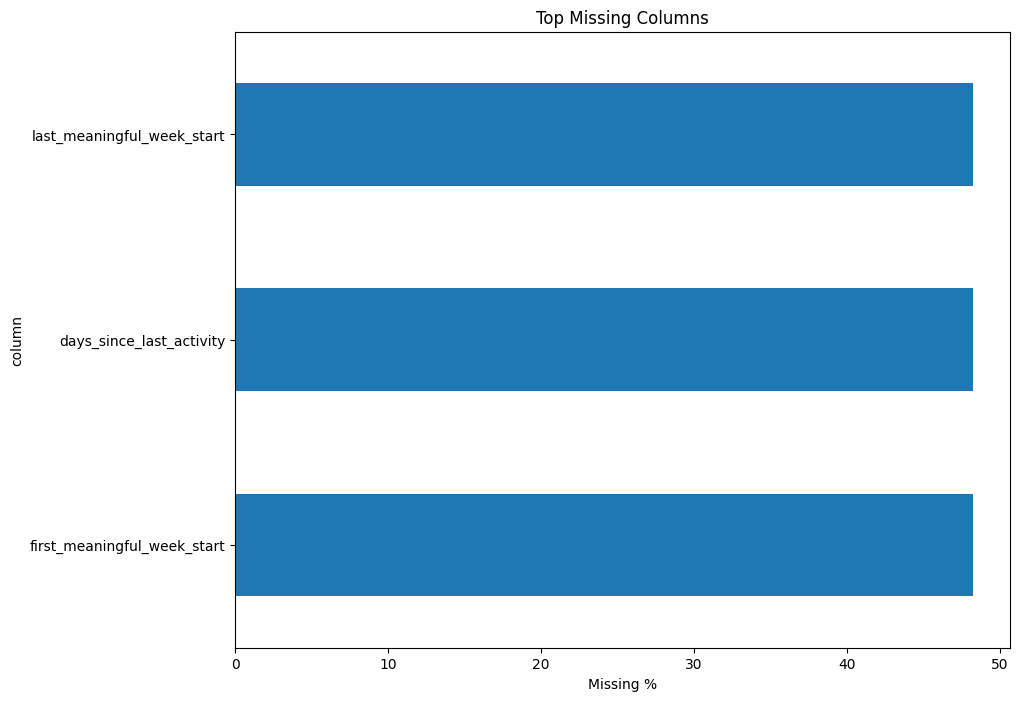

In [77]:
miss_plot = missing[missing['missing_pct'] > 0].head(30)
if len(miss_plot):
    ax = miss_plot.sort_values('missing_pct').plot.barh(x='column', y='missing_pct', figsize=(10, 8), legend=False)
    ax.set_title('Top Missing Columns')
    ax.set_xlabel('Missing %')
    plt.show()
else:
    print('No missing values detected.')

## 5. Population Overview: Activation and Dormancy

In [78]:
for col in ['is_activated', 'dormancy_status', 'dormant_flag', 'at_risk_flag']:
    if col in df.columns:
        display(df[col].value_counts(dropna=False).rename_axis(col).reset_index(name='developers')
                .assign(pct=lambda x: 100 * x['developers'] / len(df)))

,is_activated,developers,pct
0,1,7660278,81.653
1,0,1721230,18.347


,dormancy_status,developers,pct
0,Dormant,5304852,56.546
1,Unactivated,1721230,18.347
2,At_Risk,1580877,16.851
3,Active,418049,4.456
4,Cooling,356500,3.800


,dormant_flag,developers,pct
0,1,5304852,56.546
1,0,4076656,43.454


,at_risk_flag,developers,pct
0,0,7800631,83.149
1,1,1580877,16.851


In [79]:
needed = {'dormancy_status', 'days_since_last_activity'}
agg_cols = [c for c in ['activity_count_0_30d','activity_count_30_90d','lifetime_activity_count','lifetime_meaningful_weeks'] if c in df.columns]
if needed.issubset(df.columns):
    display(df.groupby('dormancy_status', dropna=False)[['days_since_last_activity'] + agg_cols]
            .agg(['count','mean','median','max']))
else:
    print('Dormancy validation skipped: missing dormancy_status or days_since_last_activity.')

days_since_last_activity                          \
                                   count     mean   median   max   
dormancy_status                                                    
Active                            204427   35.047   10.000  2264   
At_Risk                           851479  278.209  248.000  2264   
Cooling                           177009  104.299   59.000  2264   
Dormant                          3622044 1206.892 1123.000  2264   
Unactivated                            0     <NA>     <NA>  <NA>   

                activity_count_0_30d                       \
                               count  mean median     max   
dormancy_status                                             
Active                        418049 7.640  1.000  144228   
At_Risk                      1580877 0.000  0.000       0   
Cooling                       356500 0.000  0.000       0   
Dormant                      5304852 0.000  0.000       0   
Unactivated                  1721230 0.000  0.000       0   

                activity_count_30_90d                       \
                                count  mean median     max   
dormancy_status                                              
Active                         418049 5.332  0.000  272221   
At_Risk                       1580877 0.000  0.000       0   
Cooling                        356500 3.715  1.000   14610   
Dormant                       5304852 0.000  0.000       0   
Unactivated                   1721230 0.000  0.000       0   

                lifetime_activity_count                         \
                                  count   mean median      max   
dormancy_status                                                  
Active                           418049 34.901  2.000  2027375   
At_Risk                         1580877  9.354  2.000   107089   
Cooling                          356500 13.440  2.000    34322   
Dormant                         5304852  6.631  2.000    55061   
Unactivated                     1721230  0.000  0.000        0   

                lifetime_meaningful_weeks                       
                                    count  mean median     max  
dormancy_status                                                 
Active                             418049 2.564  0.000 321.000  
At_Risk                           1580877 1.413  1.000 274.000  
Cooling                            356500 1.769  0.000 246.000  
Dormant                           5304852 1.263  1.000 209.000  
Unactivated                       1721230 0.000  0.000   0.000

In [80]:
if 'days_since_last_activity' in df.columns:
    tmp = df.copy()
    tmp['days_since_bucket'] = pd.cut(tmp['days_since_last_activity'],
        bins=[-1, 30, 56, 90, 180, 365, np.inf],
        labels=['0-30','31-56','57-90','91-180','181-365','365+'])
    display(tmp['days_since_bucket'].value_counts(dropna=False).sort_index().reset_index(name='developers'))

,days_since_bucket,developers
0,0-30,175093
1,31-56,97027
2,57-90,84510
3,91-180,245113
4,181-365,554776
5,365+,3698440
6,NaN,4526549


## 6. Activity Count Distributions and Zero Inflation

In [81]:
activity_cols = [c for c in ['activity_count_0_30d','activity_count_30_90d','activity_count_90_180d','activity_count_90d','activity_count_180d','lifetime_activity_count'] if c in df.columns]
rows = []
for col in activity_cols:
    s = pd.to_numeric(df[col], errors='coerce').fillna(0)
    rows.append({'feature': col, 'zero_pct': round(100 * (s == 0).mean(), 2),
                 'nonzero_pct': round(100 * (s > 0).mean(), 2), 'mean': s.mean(),
                 'median': s.median(), 'p90': s.quantile(.90), 'p99': s.quantile(.99), 'max': s.max()})
activity_summary = pd.DataFrame(rows)
activity_summary

,feature,zero_pct,nonzero_pct,mean,median,p90,p99,max
0,activity_count_0_30d,95.540,4.460,0.340,0.000,0.000,4.000,144228
1,activity_count_30_90d,95.470,4.530,0.379,0.000,0.000,3.000,272221
2,activity_count_90_180d,94.450,5.550,0.404,0.000,0.000,3.000,354569
3,lifetime_activity_count,18.350,81.650,7.392,2.000,7.000,115.000,2027375


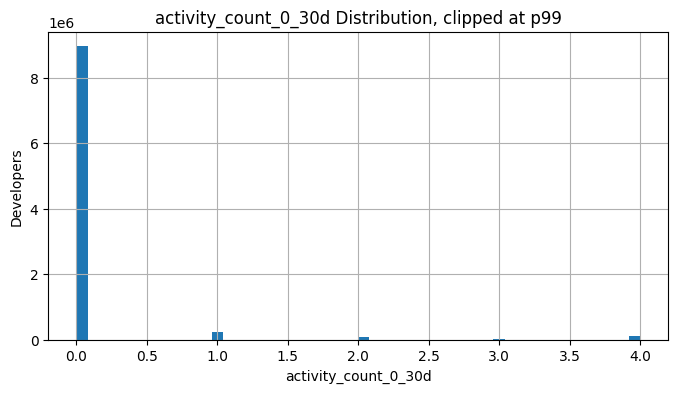

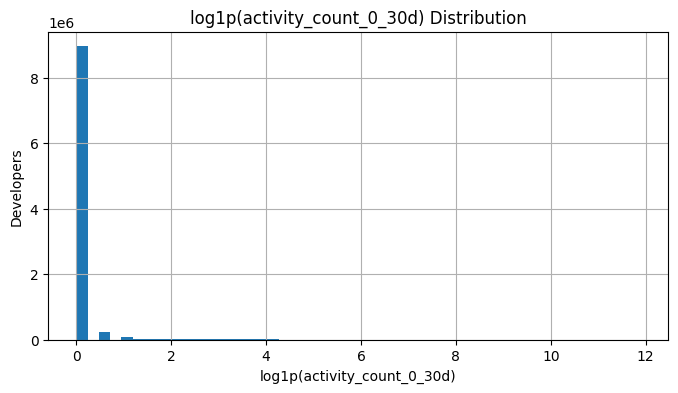

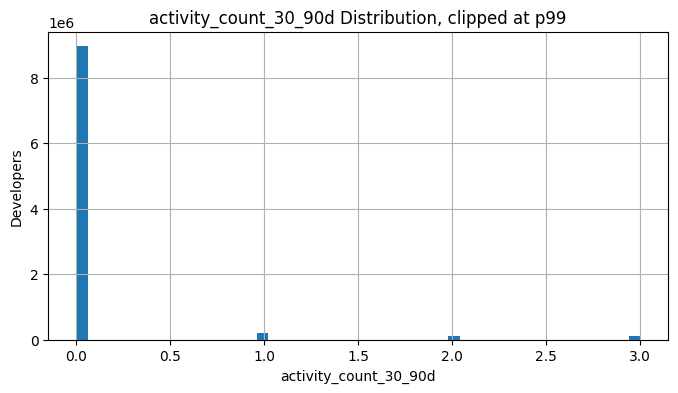

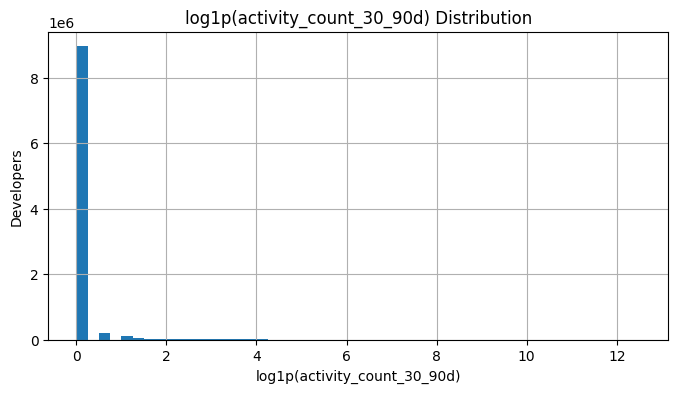

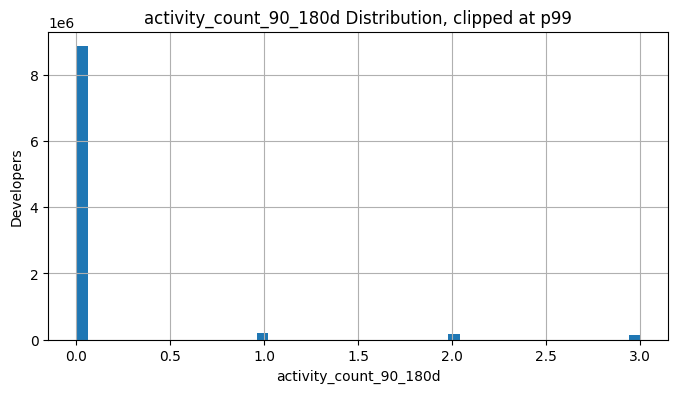

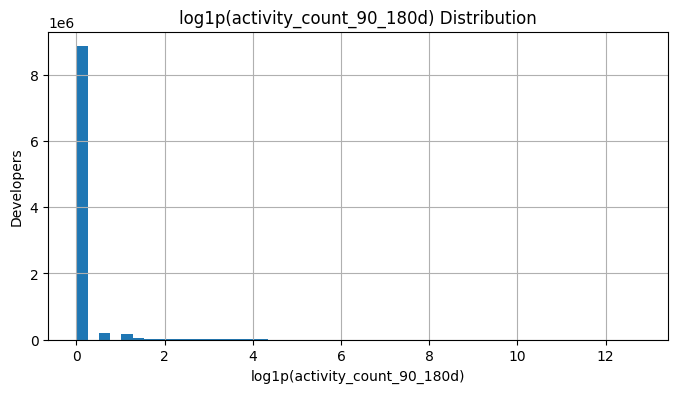

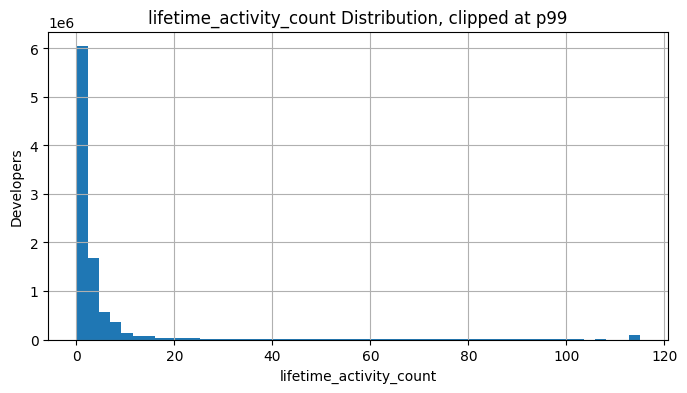

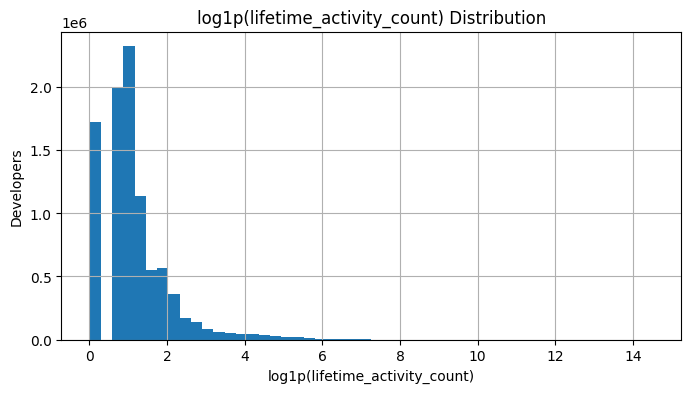

In [82]:
for col in [c for c in ['activity_count_0_30d','activity_count_30_90d','activity_count_90_180d','lifetime_activity_count'] if c in df.columns]:
    s = pd.to_numeric(df[col], errors='coerce').fillna(0)
    plt.figure(figsize=(8,4))
    s.clip(upper=s.quantile(.99)).hist(bins=50)
    plt.title(f'{col} Distribution, clipped at p99')
    plt.xlabel(col)
    plt.ylabel('Developers')
    plt.show()

    plt.figure(figsize=(8,4))
    np.log1p(s).hist(bins=50)
    plt.title(f'log1p({col}) Distribution')
    plt.xlabel(f'log1p({col})')
    plt.ylabel('Developers')
    plt.show()

## 7. Binary Flag Summary

In [83]:
binary_cols = [c for c in ['is_activated','mixed_persona_flag','recent_build_flag','recent_champion_flag','dormant_flag','at_risk_flag'] if c in df.columns]
flag_rows = []
for col in binary_cols:
    s = pd.to_numeric(df[col], errors='coerce')
    flag_rows.append({'feature': col, 'true_count': int((s == 1).sum()),
                      'true_pct': round(100 * (s == 1).mean(), 2),
                      'null_pct': round(100 * s.isna().mean(), 2)})
pd.DataFrame(flag_rows)

,feature,true_count,true_pct,null_pct
0,is_activated,7660278,81.650,0.000
1,mixed_persona_flag,2081210,22.180,0.000
2,recent_build_flag,184466,1.970,0.000
3,recent_champion_flag,7163,0.080,0.000
4,dormant_flag,5304852,56.550,0.000
5,at_risk_flag,1580877,16.850,0.000


## 8. Feature Sanity Tests

In [84]:
checks = []
def add_check(name, condition_count, severity='WARN'):
    checks.append({'check': name, 'violations': int(condition_count), 'severity': severity})

count_like = [c for c in df.columns if any(x in c for x in ['count','weeks','days_since'])]
for c in count_like:
    s = pd.to_numeric(df[c], errors='coerce')
    add_check(f'{c} has negative values', (s < 0).sum(), 'ERROR')

if {'build_count_0_30d','activity_count_0_30d'}.issubset(df.columns):
    add_check('build_count_0_30d > activity_count_0_30d', (df['build_count_0_30d'].fillna(0) > df['activity_count_0_30d'].fillna(0)).sum(), 'ERROR')
if {'high_effort_count_0_30d','activity_count_0_30d'}.issubset(df.columns):
    add_check('high_effort_count_0_30d > activity_count_0_30d', (df['high_effort_count_0_30d'].fillna(0) > df['activity_count_0_30d'].fillna(0)).sum(), 'ERROR')
if {'dormancy_status','activity_count_0_30d'}.issubset(df.columns):
    add_check('Dormant users with recent activity > 0', ((df['dormancy_status'] == 'Dormant') & (df['activity_count_0_30d'].fillna(0) > 0)).sum(), 'WARN')
if {'current_journey_state_30d','lifetime_activity_count'}.issubset(df.columns):
    add_check('Unactivated users with lifetime_activity_count > 0', ((df['current_journey_state_30d'] == 'Unactivated') & (df['lifetime_activity_count'].fillna(0) > 0)).sum(), 'WARN')
if 'developer_id' in df.columns:
    add_check('Duplicate developer_id rows in EDA dataframe', df['developer_id'].duplicated().sum(), 'ERROR')

pd.DataFrame(checks).sort_values(['severity','violations'], ascending=[True, False])

,check,violations,severity
0,activity_count_0_30d has negative values,0,ERROR
1,activity_count_30_90d has negative values,0,ERROR
2,activity_count_90_180d has negative values,0,ERROR
3,build_count_0_30d has negative values,0,ERROR
4,build_count_30_90d has negative values,0,ERROR
5,build_count_90_180d has negative values,0,ERROR
6,high_effort_count_0_30d has negative values,0,ERROR
7,high_effort_count_30_90d has negative values,0,ERROR
8,high_effort_count_90_180d has negative values,0,ERROR
9,lifetime_meaningful_weeks has negative values,0,ERROR


## 9. Journey Stage Distribution and Validation

,current_journey_state_30d,developers,pct
0,Dormant,5304852,56.546
1,Unactivated,1721230,18.347
2,At_Risk,1580877,16.851
3,Cooling,356500,3.800
4,Learner,206595,2.202
5,Builder,182281,1.943
6,Explorer,19117,0.204
7,Champion,10056,0.107


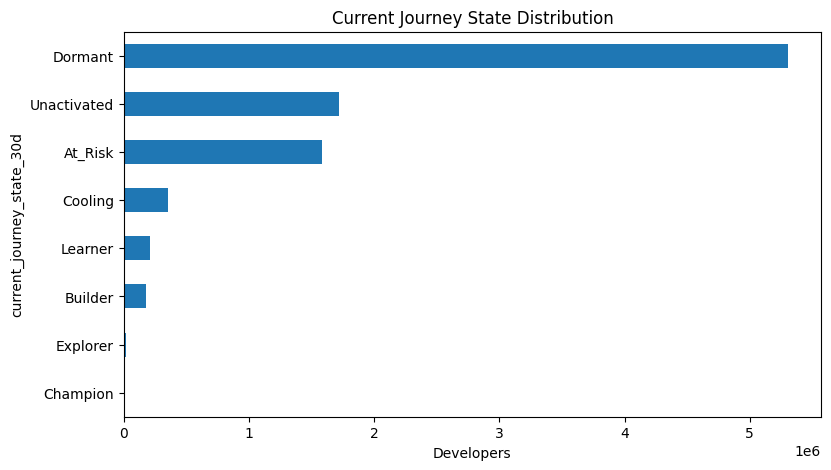

In [85]:
if 'current_journey_state_30d' in df.columns:
    stage_dist = df['current_journey_state_30d'].value_counts(dropna=False).rename_axis('current_journey_state_30d').reset_index(name='developers')
    stage_dist['pct'] = 100 * stage_dist['developers'] / len(df)
    display(stage_dist)
    ax = stage_dist.sort_values('developers').plot.barh(x='current_journey_state_30d', y='developers', legend=False, figsize=(9,5))
    ax.set_title('Current Journey State Distribution')
    ax.set_xlabel('Developers')
    plt.show()
else:
    print('current_journey_state_30d not found.')

In [86]:
stage_col = 'current_journey_state_30d'
metric_cols = [c for c in ['activity_count_0_30d','activity_count_30_90d','build_count_0_30d','high_effort_count_0_30d',
                           'unique_activity_types_0_30d','unique_modalities_0_30d','lifetime_activity_count',
                           'lifetime_build_count','lifetime_champion_count','days_since_last_activity','recent_activity_trend_ratio'] if c in df.columns]
if stage_col in df.columns and metric_cols:
    display(df.groupby(stage_col, dropna=False)[metric_cols].agg(['mean','median','count']))
else:
    print('Stage behavior table skipped.')

activity_count_0_30d                  \
                                          mean median    count   
current_journey_state_30d                                        
At_Risk                                  0.000  0.000  1580877   
Builder                                 15.835  4.000   182281   
Champion                                 4.847  2.000    10056   
Cooling                                  0.000  0.000   356500   
Dormant                                  0.000  0.000  5304852   
Explorer                                 2.402  2.000    19117   
Learner                                  1.031  1.000   206595   
Unactivated                              0.000  0.000  1721230   

                          activity_count_30_90d                  \
                                           mean median    count   
current_journey_state_30d                                         
At_Risk                                   0.000  0.000  1580877   
Builder                                  11.890  0.000   182281   
Champion                                  4.262  0.000    10056   
Cooling                                   3.715  1.000   356500   
Dormant                                   0.000  0.000  5304852   
Explorer                                  0.042  0.000    19117   
Learner                                   0.087  0.000   206595   
Unactivated                               0.000  0.000  1721230   

                          build_count_0_30d                  \
                                       mean median    count   
current_journey_state_30d                                     
At_Risk                               0.000  0.000  1580877   
Builder                              15.272  3.000   182281   
Champion                              3.197  0.000    10056   
Cooling                               0.000  0.000   356500   
Dormant                               0.000  0.000  5304852   
Explorer                              0.000  0.000    19117   
Learner                               0.000  0.000   206595   
Unactivated                           0.000  0.000  1721230   

                          high_effort_count_0_30d                  \
                                             mean median    count   
current_journey_state_30d                                           
At_Risk                                     0.000  0.000  1580877   
Builder                                    12.811  2.000   182281   
Champion                                    2.486  0.000    10056   
Cooling                                     0.000  0.000   356500   
Dormant                                     0.000  0.000  5304852   
Explorer                                    0.000  0.000    19117   
Learner                                     0.000  0.000   206595   
Unactivated                                 0.000  0.000  1721230   

                          unique_activity_types_0_30d                  \
                                                 mean median    count   
current_journey_state_30d                                               
At_Risk                                         0.000  0.000  1580877   
Builder                                         1.548  2.000   182281   
Champion                                        1.602  2.000    10056   
Cooling                                         0.000  0.000   356500   
Dormant                                         0.000  0.000  5304852   
Explorer                                        2.014  2.000    19117   
Learner                                         1.000  1.000   206595   
Unactivated                                     0.000  0.000  1721230   

                          unique_modalities_0_30d                  \
                                             mean median    count   
current_journey_state_30d                                           
At_Risk                                     0.000  0.000  1580877   
Builder                    

In [87]:
if {'current_journey_state_30d', 'dormancy_status'}.issubset(df.columns):
    display(pd.crosstab(df['current_journey_state_30d'], df['dormancy_status'], margins=True))
    display(pd.crosstab(df['current_journey_state_30d'], df['dormancy_status'], normalize='index').round(3))

dormancy_status,Active,At_Risk,Cooling,Dormant,Unactivated,All
current_journey_state_30d,,,,,,
At_Risk,0,1580877,0,0,0,1580877
Builder,182281,0,0,0,0,182281
Champion,10056,0,0,0,0,10056
Cooling,0,0,356500,0,0,356500
Dormant,0,0,0,5304852,0,5304852
Explorer,19117,0,0,0,0,19117
Learner,206595,0,0,0,0,206595
Unactivated,0,0,0,0,1721230,1721230
All,418049,1580877,356500,5304852,1721230,9381508


dormancy_status,Active,At_Risk,Cooling,Dormant,Unactivated
current_journey_state_30d,,,,,
At_Risk,0.000,1.000,0.000,0.000,0.000
Builder,1.000,0.000,0.000,0.000,0.000
Champion,1.000,0.000,0.000,0.000,0.000
Cooling,0.000,0.000,1.000,0.000,0.000
Dormant,0.000,0.000,0.000,1.000,0.000
Explorer,1.000,0.000,0.000,0.000,0.000
Learner,1.000,0.000,0.000,0.000,0.000
Unactivated,0.000,0.000,0.000,0.000,1.000


## 10. Intent and Trend Validation

In [88]:
if 'intent_signal' in df.columns:
    intent_metrics = [c for c in ['activity_count_0_30d','build_count_0_30d','high_effort_count_0_30d','lifetime_build_count'] if c in df.columns]
    display(df.groupby('intent_signal', dropna=False)[intent_metrics].agg(['count','mean','median']))
    display(df['intent_signal'].value_counts(dropna=False).reset_index(name='developers'))
else:
    print('intent_signal not found.')

activity_count_0_30d               build_count_0_30d         \
                                count   mean median             count   mean   
intent_signal                                                                  
Build_Intent                   184466 15.828  4.000            184466 15.266   
Learning_Intent                233583  1.175  1.000            233583  0.000   
No_Recent_Intent              8963459  0.000  0.000           8963459  0.000   

                        high_effort_count_0_30d                \
                 median                   count   mean median   
intent_signal                                                   
Build_Intent      3.000                  184466 12.794  2.000   
Learning_Intent   0.000                  233583  0.000  0.000   
No_Recent_Intent  0.000                 8963459  0.000  0.000   

                 lifetime_build_count                
                                count   mean median  
intent_signal                                        
Build_Intent                   184466 72.431  7.000  
Learning_Intent                233583  0.883  0.000  
No_Recent_Intent              8963459  4.519  0.000

,intent_signal,developers
0,No_Recent_Intent,8963459
1,Learning_Intent,233583
2,Build_Intent,184466


In [89]:
if 'trend_signal' in df.columns:
    trend_metrics = [c for c in ['activity_count_0_30d','activity_count_30_90d','recent_activity_trend_ratio'] if c in df.columns]
    display(df.groupby('trend_signal', dropna=False)[trend_metrics].agg(['count','mean','median']))
    display(df['trend_signal'].value_counts(dropna=False).reset_index(name='developers'))
else:
    print('trend_signal not found.')

activity_count_0_30d               activity_count_30_90d         \
                            count   mean median                 count   mean   
trend_signal                                                                   
Accelerating               372178  6.366  1.000                372178  0.477   
Declining                   30344 17.370  3.000                 30344 57.515   
Inactive                  8963459  0.000  0.000               8963459  0.148   
Stable                      15527 19.176  5.000                 15527 19.718   

                    recent_activity_trend_ratio               
             median                       count  mean median  
trend_signal                                                  
Accelerating  0.000                      372178 2.356  2.000  
Declining    13.000                       30344 0.323  0.333  
Inactive      0.000                     8963459 0.000  0.000  
Stable        5.000                       15527 1.011  1.000

,trend_signal,developers
0,Inactive,8963459
1,Accelerating,372178
2,Declining,30344
3,Stable,15527


In [90]:
if {'current_journey_state_30d','trend_signal'}.issubset(df.columns):
    display(pd.crosstab(df['current_journey_state_30d'], df['trend_signal'], margins=True))

trend_signal,Accelerating,Declining,Inactive,Stable,All
current_journey_state_30d,,,,,
At_Risk,0,0,1580877,0,1580877
Builder,142114,27303,0,12864,182281
Champion,7941,1287,0,828,10056
Cooling,0,0,356500,0,356500
Dormant,0,0,5304852,0,5304852
Explorer,19016,47,0,54,19117
Learner,203107,1707,0,1781,206595
Unactivated,0,0,1721230,0,1721230
All,372178,30344,8963459,15527,9381508


## 11. Persona and Lane Diagnostics

In [91]:
for col in ['persona','persona_confidence_tier','mixed_persona_flag']:
    if col in df.columns:
        out = df[col].value_counts(dropna=False).reset_index(name='developers')
        out['pct'] = 100 * out['developers'] / len(df)
        display(out.head(30))

,persona,developers,pct
0,CUDA,3459348,36.874
1,GenAI,2373217,25.297
2,Unknown,1875549,19.992
3,Learning_Community,595004,6.342
4,Robotics,563333,6.005
5,Simulation,515057,5.490


,persona_confidence_tier,developers,pct
0,High,4160382,44.347
1,Medium,2749477,29.307
2,Unknown,1875549,19.992
3,Low,596100,6.354


,mixed_persona_flag,developers,pct
0,0,7300298,77.816
1,1,2081210,22.184


In [92]:
if 'persona' in df.columns:
    group_metrics = {}
    for c in ['is_activated','dormant_flag','at_risk_flag','activity_count_0_30d','lifetime_activity_count']:
        if c in df.columns:
            group_metrics[c] = ['mean','median'] if c not in ['is_activated','dormant_flag','at_risk_flag'] else 'mean'
    if group_metrics:
        display(df.groupby('persona', dropna=False).agg(group_metrics))
    if 'dormancy_status' in df.columns:
        display(pd.crosstab(df['persona'], df['dormancy_status'], normalize='index').round(3))
    if 'current_journey_state_30d' in df.columns:
        display(pd.crosstab(df['persona'], df['current_journey_state_30d'], normalize='index').round(3))
else:
    print('persona not found.')

is_activated dormant_flag at_risk_flag  \
                           mean         mean         mean   
persona                                                     
CUDA                      0.997        0.772        0.178   
GenAI                     0.880        0.459        0.227   
Learning_Community        0.945        0.688        0.219   
Robotics                  0.922        0.593        0.225   
Simulation                0.887        0.740        0.108   
Unknown                   0.310        0.224        0.060   

                   activity_count_0_30d        lifetime_activity_count         
                                   mean median                    mean median  
persona                                                                        
CUDA                              0.057  0.000                   7.940  3.000  
GenAI                             1.059  0.000                   6.650  2.000  
Learning_Community                0.035  0.000                   5.541  2.000  
Robotics                          0.704  0.000                  35.563  3.000  
Simulation                        0.046  0.000                   3.046  2.000  
Unknown                           0.022  0.000                   0.638  0.000

dormancy_status,Active,At_Risk,Cooling,Dormant,Unactivated
persona,,,,,
CUDA,0.016,0.178,0.030,0.772,0.003
GenAI,0.125,0.227,0.069,0.459,0.120
Learning_Community,0.015,0.219,0.024,0.688,0.055
Robotics,0.045,0.225,0.059,0.593,0.078
Simulation,0.016,0.108,0.023,0.740,0.113
Unknown,0.012,0.060,0.015,0.224,0.690


current_journey_state_30d,At_Risk,Builder,Champion,Cooling,Dormant,Explorer,Learner,Unactivated
persona,,,,,,,,
CUDA,0.178,0.010,0.000,0.030,0.772,0.001,0.005,0.003
GenAI,0.227,0.050,0.003,0.069,0.459,0.005,0.067,0.120
Learning_Community,0.219,0.004,0.001,0.024,0.688,0.003,0.006,0.055
Robotics,0.225,0.029,0.001,0.059,0.593,0.004,0.011,0.078
Simulation,0.108,0.007,0.000,0.023,0.740,0.001,0.007,0.113
Unknown,0.060,0.003,0.000,0.015,0.224,0.000,0.009,0.690


In [93]:
lane_cols = [c for c in ['cuda_score','genai_score','robotics_score','simulation_score','learning_community_score','graphics_score','deep_learning_score'] if c in df.columns]
if lane_cols:
    lane_summary = []
    for c in lane_cols:
        s = pd.to_numeric(df[c], errors='coerce').fillna(0)
        lane_summary.append({'lane': c, 'nonzero_pct': 100*(s>0).mean(), 'mean': s.mean(), 'p90': s.quantile(.90), 'p99': s.quantile(.99), 'max': s.max()})
    display(pd.DataFrame(lane_summary).sort_values('nonzero_pct', ascending=False))
    df['lane_breadth'] = sum((pd.to_numeric(df[c], errors='coerce').fillna(0) > 0).astype(int) for c in lane_cols)
    display(df['lane_breadth'].value_counts().sort_index().reset_index(name='developers'))
    if 'current_journey_state_30d' in df.columns:
        display(df.groupby('current_journey_state_30d')['lane_breadth'].agg(['count','mean','median']))
else:
    print('No lane score columns found.')

,lane,nonzero_pct,mean,p90,p99,max
0,cuda_score,41.048,8.692,12.000,135.000,1271559.000
4,learning_community_score,27.208,2.070,4.000,30.000,35432.000
1,genai_score,16.987,2.498,3.000,30.000,1983186.000
2,robotics_score,7.225,5.834,0.000,156.000,252444.000
3,simulation_score,5.198,0.505,0.000,9.000,415011.000


,lane_breadth,developers
0,0,4122818
1,1,2632685
2,2,1756329
3,3,565947
4,4,199351
5,5,104378


,count,mean,median
current_journey_state_30d,,,
At_Risk,1580877,1.218,1.000
Builder,182281,0.892,0.000
Champion,10056,2.310,2.000
Cooling,356500,1.019,1.000
Dormant,5304852,1.249,1.000
Explorer,19117,1.051,1.000
Learner,206595,0.194,0.000
Unactivated,1721230,0.000,0.000


## 12. Window Relationships and Correlation Checks

,activity_count_0_30d,activity_count_30_90d,activity_count_90_180d,build_count_0_30d,high_effort_count_0_30d,unique_activity_types_0_30d,lifetime_activity_count,lifetime_build_count,lifetime_champion_count,days_since_last_activity,recent_activity_trend_ratio
activity_count_0_30d,1.000,0.350,0.121,0.926,0.833,0.820,0.226,0.243,-0.001,-0.091,0.438
activity_count_30_90d,0.350,1.000,0.246,0.391,0.386,0.171,0.248,0.251,0.014,-0.043,0.069
activity_count_90_180d,0.121,0.246,1.000,0.140,0.120,0.049,0.246,0.219,0.051,-0.002,0.012
build_count_0_30d,0.926,0.391,0.140,1.000,0.905,0.586,0.264,0.300,-0.006,-0.043,0.355
high_effort_count_0_30d,0.833,0.386,0.120,0.905,1.000,0.505,0.232,0.266,-0.006,-0.041,0.315
unique_activity_types_0_30d,0.820,0.171,0.049,0.586,0.505,1.000,0.110,0.104,0.001,-0.125,0.407
lifetime_activity_count,0.226,0.248,0.246,0.264,0.232,0.110,1.000,0.868,0.117,0.581,0.068
lifetime_build_count,0.243,0.251,0.219,0.300,0.266,0.104,0.868,1.000,-0.033,0.563,0.069
lifetime_champion_count,-0.001,0.014,0.051,-0.006,-0.006,0.001,0.117,-0.033,1.000,0.133,-0.003
days_since_last_activity,-0.091,-0.043,-0.002,-0.043,-0.041,-0.125,0.581,0.563,0.133,1.000,-0.058


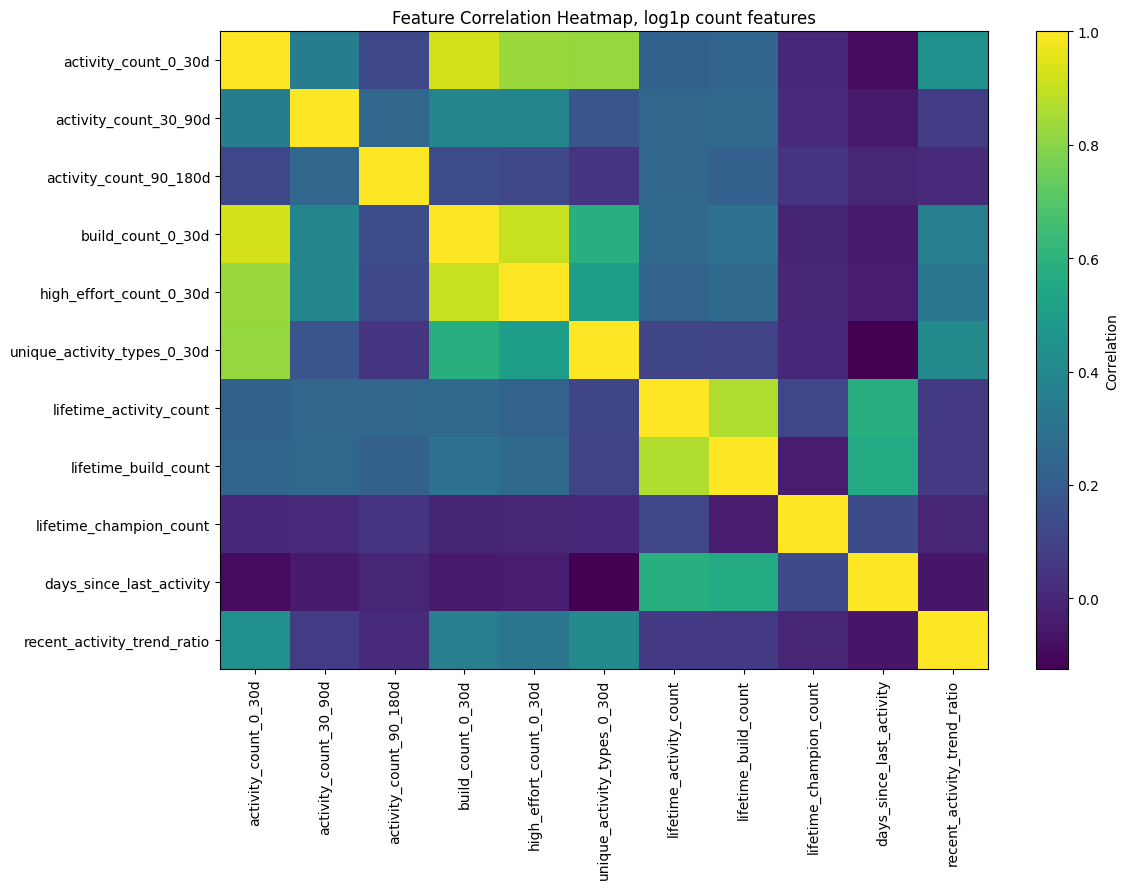

In [94]:
corr_cols = [c for c in ['activity_count_0_30d','activity_count_30_90d','activity_count_90_180d',
                         'build_count_0_30d','high_effort_count_0_30d','unique_activity_types_0_30d',
                         'lifetime_activity_count','lifetime_build_count','lifetime_champion_count',
                         'days_since_last_activity','recent_activity_trend_ratio'] if c in df.columns]
if len(corr_cols) >= 2:
    corr_df = df[corr_cols].apply(pd.to_numeric, errors='coerce').fillna(0)
    log_cols = [c for c in corr_cols if c != 'recent_activity_trend_ratio']
    corr_df[log_cols] = np.log1p(corr_df[log_cols].clip(lower=0))
    corr = corr_df.corr()
    display(corr.round(3))
    plt.figure(figsize=(12,9))
    plt.imshow(corr, aspect='auto')
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
    plt.yticks(range(len(corr.index)), corr.index)
    plt.colorbar(label='Correlation')
    plt.title('Feature Correlation Heatmap, log1p count features')
    plt.tight_layout()
    plt.show()
else:
    print('Not enough numeric columns for correlation.')

## 13. Outlier Inspection

In [95]:
for col in [c for c in ['activity_count_0_30d','lifetime_activity_count','build_count_0_30d','lifetime_build_count'] if c in df.columns]:
    print(f'Top developers by {col}')
    display(df.sort_values(col, ascending=False)[['developer_id', col] + [c for c in ['current_journey_state_30d','dormancy_status','intent_signal','trend_signal','persona'] if c in df.columns]].head(10))

Top developers by activity_count_0_30d


,developer_id,activity_count_0_30d,current_journey_state_30d,dormancy_status,intent_signal,trend_signal,persona
2181706,5903679,144228,Builder,Active,Build_Intent,Declining,GenAI
753499,5886356,17093,Builder,Active,Build_Intent,Accelerating,GenAI
4752310,8388704,8532,Builder,Active,Build_Intent,Accelerating,GenAI
5476200,7938574,5023,Builder,Active,Build_Intent,Declining,GenAI
3463546,10253624,3463,Builder,Active,Build_Intent,Accelerating,GenAI
8281631,9633953,3223,Builder,Active,Build_Intent,Declining,GenAI
1661777,6112577,2916,Builder,Active,Build_Intent,Declining,CUDA
989010,10166300,2825,Builder,Active,Build_Intent,Accelerating,GenAI
3547701,6615500,2477,Builder,Active,Build_Intent,Accelerating,GenAI
5325465,5671110,2425,Builder,Active,Build_Intent,Declining,GenAI


Top developers by lifetime_activity_count


,developer_id,lifetime_activity_count,current_journey_state_30d,dormancy_status,intent_signal,trend_signal,persona
2181706,5903679,2027375,Builder,Active,Build_Intent,Declining,GenAI
753499,5886356,789400,Builder,Active,Build_Intent,Accelerating,GenAI
4306120,3931685,187095,Builder,Active,Build_Intent,Declining,GenAI
938782,1303597,151947,Builder,Active,Build_Intent,Declining,Robotics
7829645,2028858,142980,Builder,Active,Build_Intent,Declining,GenAI
7011734,6309430,121950,Builder,Active,Build_Intent,Declining,GenAI
6753605,4634152,107089,At_Risk,At_Risk,No_Recent_Intent,Inactive,Robotics
7867079,6125204,68992,Builder,Active,Build_Intent,Accelerating,CUDA
181240,4833930,55061,Dormant,Dormant,No_Recent_Intent,Inactive,CUDA
7640097,225774,53677,Dormant,Dormant,No_Recent_Intent,Inactive,CUDA


Top developers by build_count_0_30d


,developer_id,build_count_0_30d,current_journey_state_30d,dormancy_status,intent_signal,trend_signal,persona
2181706,5903679,144228.000,Builder,Active,Build_Intent,Declining,GenAI
753499,5886356,17093.000,Builder,Active,Build_Intent,Accelerating,GenAI
4752310,8388704,8531.000,Builder,Active,Build_Intent,Accelerating,GenAI
5476200,7938574,5023.000,Builder,Active,Build_Intent,Declining,GenAI
3463546,10253624,3462.000,Builder,Active,Build_Intent,Accelerating,GenAI
8281631,9633953,3223.000,Builder,Active,Build_Intent,Declining,GenAI
1661777,6112577,2916.000,Builder,Active,Build_Intent,Declining,CUDA
989010,10166300,2825.000,Builder,Active,Build_Intent,Accelerating,GenAI
3547701,6615500,2477.000,Builder,Active,Build_Intent,Accelerating,GenAI
5325465,5671110,2425.000,Builder,Active,Build_Intent,Declining,GenAI


Top developers by lifetime_build_count


,developer_id,lifetime_build_count,current_journey_state_30d,dormancy_status,intent_signal,trend_signal,persona
2181706,5903679,2027374.000,Builder,Active,Build_Intent,Declining,GenAI
753499,5886356,789396.000,Builder,Active,Build_Intent,Accelerating,GenAI
4306120,3931685,187095.000,Builder,Active,Build_Intent,Declining,GenAI
938782,1303597,151937.000,Builder,Active,Build_Intent,Declining,Robotics
7829645,2028858,142980.000,Builder,Active,Build_Intent,Declining,GenAI
7011734,6309430,121938.000,Builder,Active,Build_Intent,Declining,GenAI
6753605,4634152,107089.000,At_Risk,At_Risk,No_Recent_Intent,Inactive,Robotics
7867079,6125204,68919.000,Builder,Active,Build_Intent,Accelerating,CUDA
181240,4833930,55060.000,Dormant,Dormant,No_Recent_Intent,Inactive,CUDA
7640097,225774,53677.000,Dormant,Dormant,No_Recent_Intent,Inactive,CUDA


## 14. Activity Ontology Diagnostics

In [96]:
if TABLES['ontology']:
    ontology_cols = cols(TABLES['ontology'])
    tags = [c for c in ['journey_signal','effort_level','persona_hint','modality','lead_source'] if c in ontology_cols]
    for tag in tags:
        print(f'{tag}')
        display(con.execute(f'''
            SELECT {tag} AS value,
                   COUNT(*) AS events,
                   ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct
            FROM {TABLES['ontology']}
            GROUP BY 1
            ORDER BY events DESC
        ''').fetchdf())
else:
    print('No ontology table found.')

journey_signal


,value,events,pct
0,Build,54072000,77.970
1,Discover,13014716,18.770
2,Learn,1721219,2.480
3,Champion,529890,0.760
4,Evaluate,9676,0.010


effort_level


,value,events,pct
0,Moderate,44064193,63.540
1,Passive,13297649,19.180
2,High,11985659,17.280


persona_hint


,value,events,pct
0,CUDA,27182722,39.200
1,Other,23290799,33.590
2,Robotics,11000602,15.860
3,GenAI,5049967,7.280
4,Learning_Community,2000883,2.890
5,Simulation,822528,1.190


modality


,value,events,pct
0,Download,47462671,68.440
1,Content,10532251,15.190
2,Hosted API,6478579,9.340
3,Event,2007615,2.900
4,Training,1958700,2.820
5,Community,784576,1.130
6,Cloud Workspace,123109,0.180


lead_source


,value,events,pct
0,unknown,57429863,82.810
1,gseo,4333091,6.250
2,website,3169388,4.570
3,ref,3067039,4.420
4,bseo,1041171,1.500
...,...,...,...
490,https://brev.nvidia.com/org/org-37dcvux1qklpzl...,1,0.000
491,https://brev.nvidia.com/launchables/create?gpu...,1,0.000
492,nala_dev_wbn_202411_dl01_test,1,0.000
493,https://notebooks.githubusercontent.com/,1,0.000


## 15. Final Findings Template

In [97]:
print('=' * 80)
print('FINAL EDA CHECKLIST')
print('=' * 80)
if 'current_journey_state_30d' in df.columns:
    print('Journey stage distribution:')
    print(df['current_journey_state_30d'].value_counts(normalize=True).mul(100).round(2).head(20))
if 'dormancy_status' in df.columns:
    print('Dormancy distribution:')
    print(df['dormancy_status'].value_counts(normalize=True).mul(100).round(2))
if 'intent_signal' in df.columns:
    print('Intent distribution:')
    print(df['intent_signal'].value_counts(normalize=True).mul(100).round(2))
if 'trend_signal' in df.columns:
    print('Trend distribution:')
    print(df['trend_signal'].value_counts(normalize=True).mul(100).round(2))
print('Review the sanity check table above. Any ERROR with violations should be investigated before modeling.')

FINAL EDA CHECKLIST
Journey stage distribution:
current_journey_state_30d
Dormant       56.550
Unactivated   18.350
At_Risk       16.850
Cooling        3.800
Learner        2.200
Builder        1.940
Explorer       0.200
Champion       0.110
Name: proportion, dtype: float64
Dormancy distribution:
dormancy_status
Dormant       56.550
Unactivated   18.350
At_Risk       16.850
Active         4.460
Cooling        3.800
Name: proportion, dtype: float64
Intent distribution:
intent_signal
No_Recent_Intent   95.540
Learning_Intent     2.490
Build_Intent        1.970
Name: proportion, dtype: float64
Trend distribution:
trend_signal
Inactive       95.540
Accelerating    3.970
Declining       0.320
Stable          0.170
Name: proportion, dtype: float64
Review the sanity check table above. Any ERROR with violations should be investigated before modeling.


In [101]:
con.execute("""
SELECT
    activity,
    COUNT(*) AS events,
    COUNT(DISTINCT journey_signal) AS n_journey_signals,
    COUNT(DISTINCT effort_level) AS n_effort_levels,
    COUNT(DISTINCT modality) AS n_modalities
FROM activity_ontology_v2
GROUP BY activity
HAVING COUNT(DISTINCT journey_signal) > 1
    OR COUNT(DISTINCT effort_level) > 1
    OR COUNT(DISTINCT modality) > 1
ORDER BY n_journey_signals DESC, events DESC;
""").fetchdf()

,activity,events,n_journey_signals,n_effort_levels,n_modalities
0,webinars,320007,4,3,5
1,brev,121821,3,3,5
2,dev program membership,6767607,2,2,1
3,dli training,1934108,2,1,1
4,on-demand views,1440586,2,2,1
5,conf. sessions live,1312509,2,2,1
6,conference,401436,2,2,1
7,bugs filed,115133,2,2,1
8,devzone downloads,39742594,1,2,1
9,ngc downloads,7720077,1,2,1


In [102]:
con.close()